# E-Commerce Sales Analysis
## Part 1: Exploratory Data Analysis (EDA)

**Dataset:** E-Commerce Sales dataset (2,000+ orders, Jan 2024 – Dec 2025)

**Objective:** Explore the dataset's structure, check data quality, identify patterns/anomalies, and validate assumptions using statistics — before any visual storytelling happens.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/ecommerce_sales.csv", parse_dates=["Order_Date", "Ship_Date"])
df.shape

(2015, 15)

## 1. Understanding the Data Structure
What variables do we have, and what types are they?

In [2]:
df.head()

,Order_ID,Order_Date,Ship_Date,Category,Region,Customer_Segment,Payment_Mode,Ship_Mode,Quantity,Unit_Price,Discount_Percent,Sales,Profit,Customer_Age,Customer_Rating
0,ORD11137,2024-01-01,2024-01-06,Electronics,West,Consumer,UPI,Standard,2,26811.28,10,48260.30,8468.06,62.0,5.0
1,ORD10755,2024-01-01,2024-01-04,Fashion,North,Consumer,Cash on Delivery,Standard,1,4223.85,0,4223.85,1136.47,40.0,5.0
2,ORD10979,2024-01-01,2024-01-06,Fashion,Central,Consumer,Debit Card,Standard,1,2584.41,0,2584.41,832.09,50.0,4.0
3,ORD10648,2024-01-01,2024-01-01,Fashion,West,Corporate,Net Banking,Same Day,1,4508.44,30,3155.91,400.06,29.0,4.0
4,ORD11977,2024-01-01,2024-01-05,Beauty,Central,Corporate,UPI,Standard,1,191.21,10,172.09,41.24,52.0,3.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2015 non-null   str           
 1   Order_Date        2015 non-null   datetime64[us]
 2   Ship_Date         2015 non-null   datetime64[us]
 3   Category          2015 non-null   str           
 4   Region            2015 non-null   str           
 5   Customer_Segment  2015 non-null   str           
 6   Payment_Mode      2015 non-null   str           
 7   Ship_Mode         2015 non-null   str           
 8   Quantity          2015 non-null   int64         
 9   Unit_Price        2015 non-null   float64       
 10  Discount_Percent  2015 non-null   int64         
 11  Sales             2015 non-null   float64       
 12  Profit            2015 non-null   float64       
 13  Customer_Age      1950 non-null   float64       
 14  Customer_Rating   1311 non-null   f

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_ID,2015,2000,ORD11180,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,2015,NaN,NaN,NaN,2024-12-23 04:35:51.066997,2024-01-01 00:00:00,2024-06-16 00:00:00,2024-12-18 00:00:00,2025-06-25 12:00:00,2025-12-31 00:00:00,NaN
Ship_Date,2015,NaN,NaN,NaN,2024-12-26 07:48:05.359801,2024-01-01 00:00:00,2024-06-19 00:00:00,2024-12-22 00:00:00,2025-06-29 00:00:00,2026-01-06 00:00:00,NaN
Category,2015,7,Fashion,421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,2015,5,West,484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Segment,2015,3,Consumer,1102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Mode,2015,5,UPI,697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship_Mode,2015,3,Standard,1214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,2015.0,NaN,NaN,NaN,1.631762,1.0,1.0,1.0,2.0,5.0,0.976071
Unit_Price,2015.0,NaN,NaN,NaN,9427.006199,100.66,1494.175,3453.7,9682.715,59993.72,13801.515008


## 2. Data Quality Check
Before drawing any conclusions, check for missing values and duplicate records — common real-world data issues.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct}).query("`Missing Count` > 0")

,Missing Count,Missing %
Customer_Age,65,3.23
Customer_Rating,704,34.94


In [6]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 15
Shape after removing duplicates: (2000, 15)


In [7]:
# Median-fill Customer_Age; keep Customer_Rating NaN as "not rated" (analyzed separately)
df["Customer_Age"] = df["Customer_Age"].fillna(df["Customer_Age"].median())
not_rated_pct = round(df["Customer_Rating"].isnull().mean() * 100, 2)
print(f"Orders never rated by customer: {not_rated_pct}%")
df.isnull().sum()

Orders never rated by customer: 34.75%


Order_ID              0
Order_Date            0
Ship_Date             0
Category              0
Region                0
Customer_Segment      0
Payment_Mode          0
Ship_Mode             0
Quantity              0
Unit_Price            0
Discount_Percent      0
Sales                 0
Profit                0
Customer_Age          0
Customer_Rating     695
dtype: int64

## 3. Univariate Analysis
Understanding individual variable distributions.

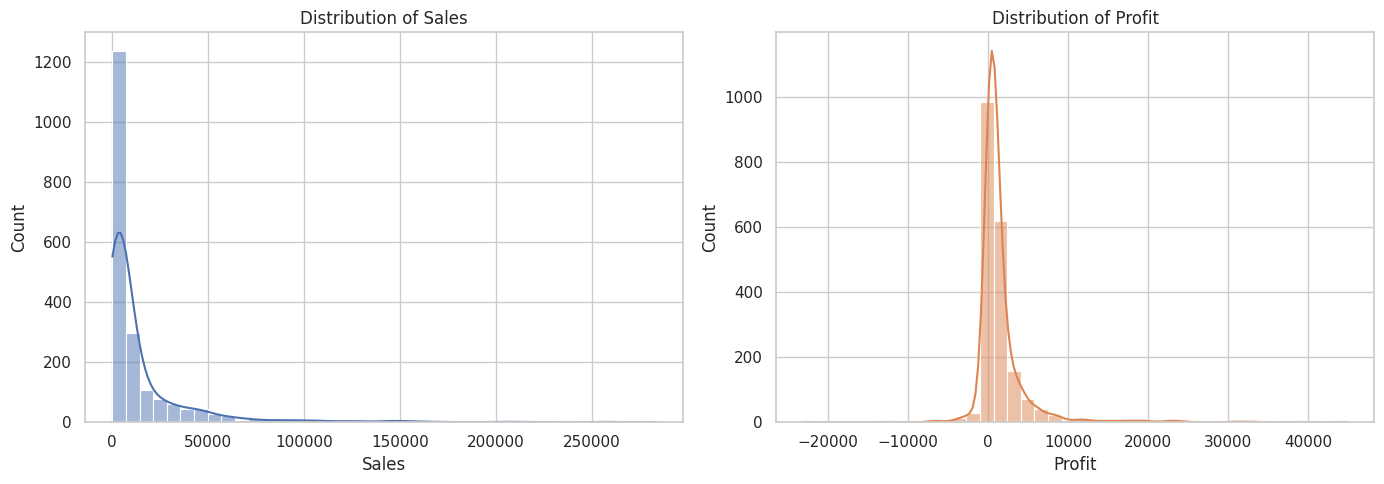

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Sales"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Sales")
sns.histplot(df["Profit"], bins=40, kde=True, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of Profit")
plt.tight_layout()
plt.show()

In [9]:
df["Category"].value_counts()

Category
Fashion           420
Electronics       416
Home & Kitchen    319
Sports            258
Beauty            246
Toys              171
Books             170
Name: count, dtype: int64

## 4. Statistical Validation: Does Discount Actually Hurt Profit?
Testing the assumption with groupby statistics before visualizing it.

In [10]:
discount_profit_stats = df.groupby("Discount_Percent")["Profit"].agg(["mean", "median", "std", "count"])
discount_profit_stats

,mean,median,std,count
Discount_Percent,,,,
0,2352.039430,902.240,4712.721170,509
5,1813.560618,875.555,3320.611673,372
10,1537.909927,615.320,3194.447661,410
15,866.616634,502.845,2371.059045,306
20,1004.836570,477.740,2581.181725,207
25,523.402266,360.240,1429.492805,128
30,133.837647,300.490,2107.979703,68


In [11]:
corr_value = df[["Discount_Percent", "Profit"]].corr().iloc[0, 1]
print(f"Correlation between Discount % and Profit: {corr_value:.3f}")

Correlation between Discount % and Profit: -0.181


## 5. Correlation Analysis Across Numeric Features

In [12]:
numeric_cols = ["Quantity", "Unit_Price", "Discount_Percent", "Sales", "Profit", "Customer_Age", "Customer_Rating"]
corr = df[numeric_cols].corr()
corr

,Quantity,Unit_Price,Discount_Percent,Sales,Profit,Customer_Age,Customer_Rating
Quantity,1.000000,0.032604,-0.017493,0.373226,0.336381,-0.004225,0.061179
Unit_Price,0.032604,1.000000,0.035802,0.784728,0.444492,-0.027029,0.008264
Discount_Percent,-0.017493,0.035802,1.000000,-0.043919,-0.180666,-0.004119,-0.058011
Sales,0.373226,0.784728,-0.043919,1.000000,0.685625,-0.035197,-0.002423
Profit,0.336381,0.444492,-0.180666,0.685625,1.000000,0.004396,-0.007960
Customer_Age,-0.004225,-0.027029,-0.004119,-0.035197,0.004396,1.000000,-0.003863
Customer_Rating,0.061179,0.008264,-0.058011,-0.002423,-0.007960,-0.003863,1.000000


## 6. Anomaly / Outlier Detection

In [13]:
for col in ["Sales", "Profit"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected (outside [{lower:.0f}, {upper:.0f}])")

Sales: 268 outliers detected (outside [-14975, 29773])
Profit: 258 outliers detected (outside [-1800, 3558])


In [14]:
loss_orders = df[df["Profit"] < 0]
print(f"Orders resulting in a loss: {len(loss_orders)} ({len(loss_orders)/len(df)*100:.1f}% of all orders)")
loss_orders["Discount_Percent"].value_counts().sort_index()

Orders resulting in a loss: 130 (6.5% of all orders)


Discount_Percent
0     13
5     11
10    19
15    31
20    26
25    15
30    15
Name: count, dtype: int64

## 7. EDA Summary — Key Findings

- Dataset had **duplicate rows** and **missing values** in `Customer_Age` and `Customer_Rating`; both were cleaned/handled before analysis.
- ~35% of orders were **never rated** by the customer — a data gap worth flagging operationally.
- There's a **negative correlation** between discount percentage and profit — confirming the assumption that heavier discounting erodes margins.
- A small but meaningful number of orders are **loss-making**, concentrated at the higher discount tiers (25–30%).
- Outlier detection on Sales and Profit flags a handful of unusually large orders — worth a closer look before any modeling.

➡️ These findings are visualized in detail in **Task 3: Data Visualization** (`Task3_DataVisualization.ipynb`).
